# ALDIMI - Forecast de Demanda de Medicamentos (CRISP-DM)

**Series temporales**  
**Dataset principal:** Pharma Sales Data (salesdaily.csv)  
**Horizontes de prediccion:** 7 y 14 dias

## 1) Business Understanding

ALDIMI requiere estimar demanda de medicamentos para reducir quiebres de stock y mejorar decisiones de abastecimiento.

### Problema de negocio
- Predecir demanda diaria de un analgesico/antipiretico (ATC `N02BE`).
- Entregar estimaciones en horizontes operativos de **7** y **14** dias.
- Usar resultados como entrada para compras y priorizacion logistica.

### Metricas de exito
- **MAE**: error promedio absoluto.
- **RMSE**: penaliza mas los errores grandes.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid", context="talk")

In [2]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def temporal_train_test_split(X, y, test_size=0.2):
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
    y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()
    return X_train, X_test, y_train, y_test


def summarize_metrics(model_name, horizon, y_true, y_pred):
    return {
        "Model": model_name,
        "Horizon_days": horizon,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
    }


def plot_predictions(pred_df, title, last_n=120):
    view = pred_df.tail(last_n)
    plt.figure(figsize=(14, 5))
    plt.plot(view.index, view["actual"], label="Real", linewidth=2)
    plt.plot(view.index, view["predicted"], label="Prediccion", linewidth=2)
    plt.title(title)
    plt.xlabel("Fecha")
    plt.ylabel("Demanda")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 2) Data Understanding (EDA)

In [3]:
def locate_salesdaily_csv():
    candidates = [
        Path("salesdaily.csv"),
        Path("../pharmasalesdata/salesdaily.csv"),
        Path("../../pharmasalesdata/salesdaily.csv"),
        Path(r"c:/Users/jg153/Downloads/pharmasalesdata/salesdaily.csv"),
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    for root in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
        if root.exists():
            matches = list(root.rglob("salesdaily.csv"))
            if matches:
                return matches[0].resolve()

    raise FileNotFoundError("No se encontro salesdaily.csv. Ajusta la ruta en locate_salesdaily_csv().")


data_path = locate_salesdaily_csv()
print(f"Archivo encontrado: {data_path}")

raw_df = pd.read_csv(data_path)
raw_df.head()

Archivo encontrado: C:\Users\jg153\Downloads\pharmasalesdata\salesdaily.csv


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [4]:
target_col = "N02BE"
atc_cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

df = raw_df.copy()
df = df.rename(columns={"datum": "date"})
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y", errors="coerce")

for col in atc_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values("date").dropna(subset=["date"])
df = df.drop_duplicates(subset=["date"], keep="first")
df = df.set_index("date").asfreq("D")

# Supuesto de negocio: fecha sin registro equivale a demanda observada cero.
df[atc_cols] = df[atc_cols].fillna(0.0)

print("Rango temporal:", df.index.min().date(), "->", df.index.max().date())
print("Total registros diarios:", len(df))
print("\nMissing values por columna (top 10):")
display(df.isna().sum().sort_values(ascending=False).head(10))

df[[target_col]].describe().T

Rango temporal: 2014-01-02 -> 2019-10-08
Total registros diarios: 2106

Missing values por columna (top 10):


M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
Year     0
Month    0
dtype: int64

,count,mean,std,min,25%,50%,75%,max
N02BE,2106.0,29.917095,15.590966,0.0,19.0,26.9,38.3,161.0


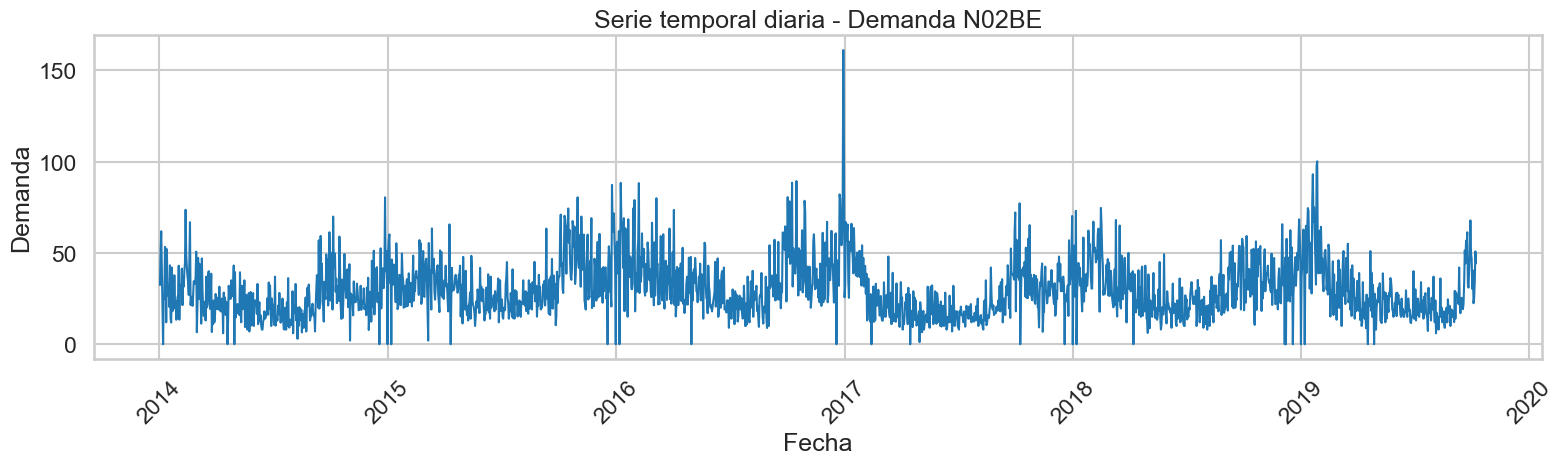

In [5]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df[target_col], color="#1f77b4", linewidth=1.5)
plt.title(f"Serie temporal diaria - Demanda {target_col}")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

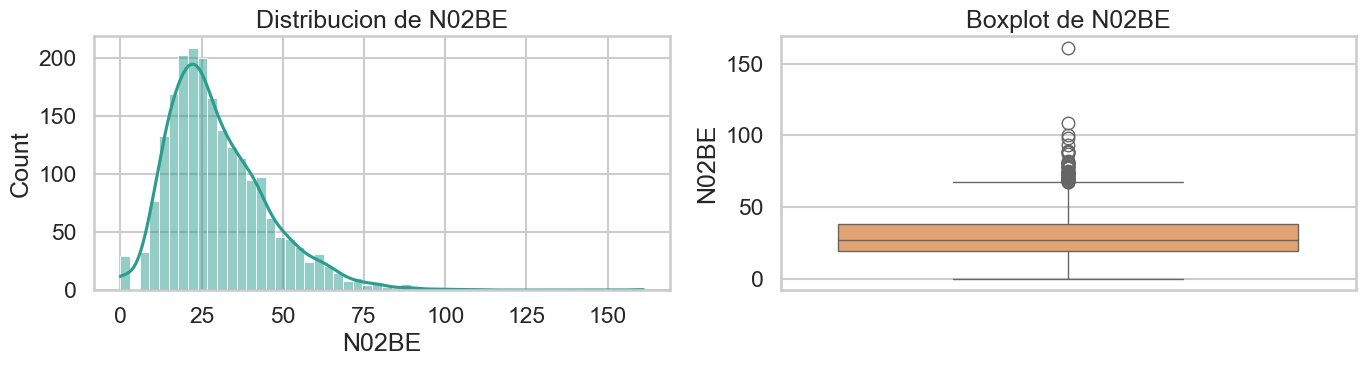

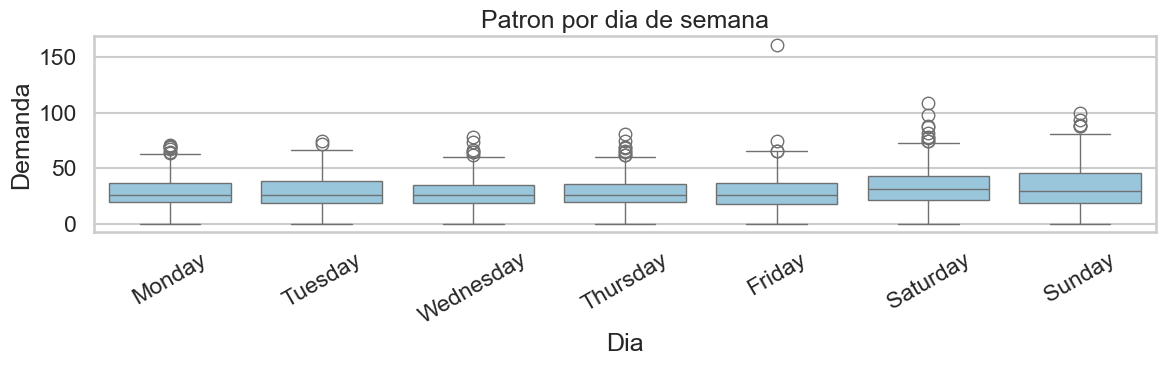

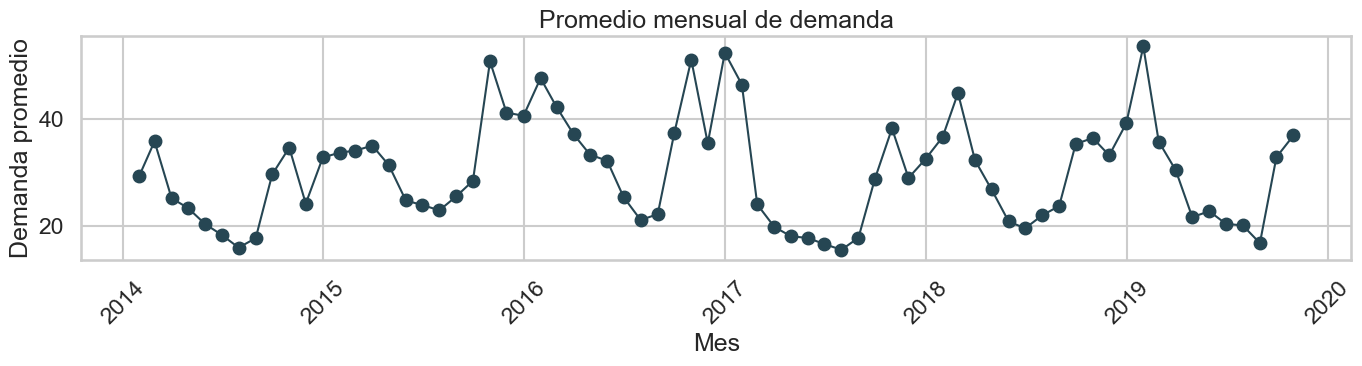

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[target_col], kde=True, ax=axes[0], color="#2a9d8f")
axes[0].set_title(f"Distribucion de {target_col}")

sns.boxplot(y=df[target_col], ax=axes[1], color="#f4a261")
axes[1].set_title(f"Boxplot de {target_col}")
plt.tight_layout()
plt.show()

tmp = df[[target_col]].copy()
tmp["weekday"] = tmp.index.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(12, 4))
sns.boxplot(data=tmp, x="weekday", y=target_col, order=weekday_order, color="#8ecae6")
plt.title("Patron por dia de semana")
plt.xlabel("Dia")
plt.ylabel("Demanda")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

monthly_mean = df[target_col].resample("ME").mean()
plt.figure(figsize=(14, 4))
plt.plot(monthly_mean.index, monthly_mean.values, marker="o", linewidth=1.5, color="#264653")
plt.title("Promedio mensual de demanda")
plt.xlabel("Mes")
plt.ylabel("Demanda promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

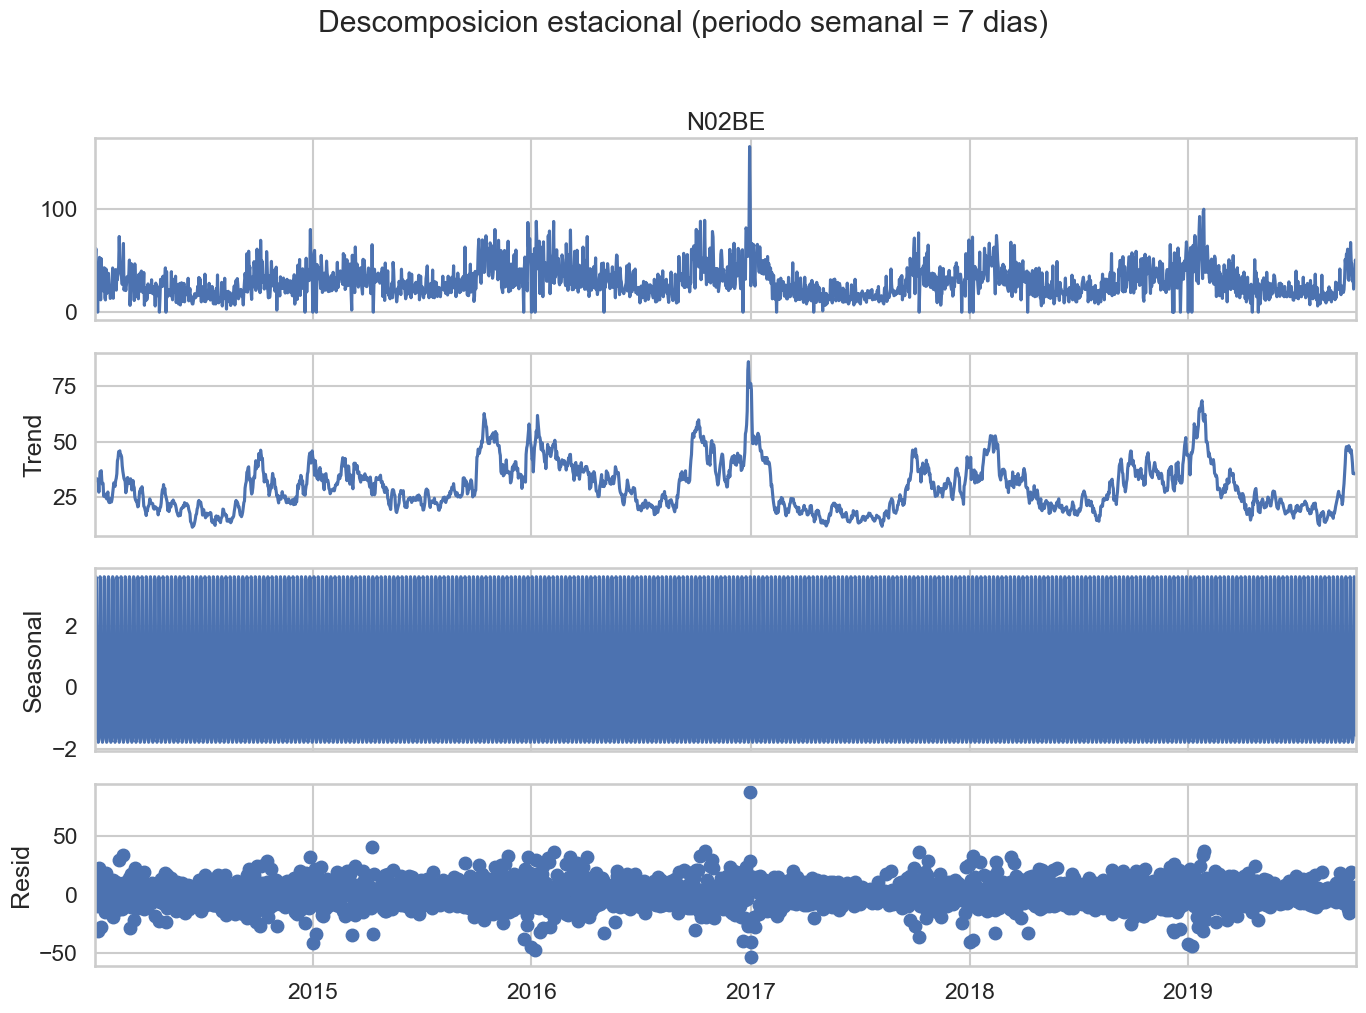

In [8]:
decomp = seasonal_decompose(df[target_col], model="additive", period=7)
fig = decomp.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Descomposicion estacional (periodo semanal = 7 dias)", y=1.02)
plt.tight_layout()
plt.show()

## 3) Data Preparation

Se construyen features temporales y autoregresivas sin fuga de informacion:
- Lags: t-1, t-7, t-14
- Rolling means desplazadas (7 y 14)
- Variables de calendario (dia de semana, mes)

In [9]:
def make_supervised_features(series, horizon):
    data = pd.DataFrame(index=series.index)
    data["lag_1"] = series.shift(1)
    data["lag_7"] = series.shift(7)
    data["lag_14"] = series.shift(14)
    data["rolling_mean_7"] = series.shift(1).rolling(window=7).mean()
    data["rolling_mean_14"] = series.shift(1).rolling(window=14).mean()
    data["day_of_week"] = series.index.dayofweek.astype("category")
    data["month"] = series.index.month.astype("category")
    data["target"] = series.shift(-horizon)

    supervised = data.dropna().copy()
    X = supervised.drop(columns="target")
    y = supervised["target"]
    return X, y, supervised

In [10]:
horizons = [7, 14]
supervised_data = {}

for h in horizons:
    X, y, sup = make_supervised_features(df[target_col], horizon=h)
    supervised_data[h] = {"X": X, "y": y, "data": sup}
    print(f"Horizonte t+{h}: X={X.shape}, y={y.shape}, fecha_min={X.index.min().date()}, fecha_max={X.index.max().date()}")

Horizonte t+7: X=(2085, 7), y=(2085,), fecha_min=2014-01-16, fecha_max=2019-10-01
Horizonte t+14: X=(2078, 7), y=(2078,), fecha_min=2014-01-16, fecha_max=2019-09-24


## 4) Modeling (Baseline)

Se usa **Regresion Lineal** como baseline interpretable sobre features de rezagos y calendario.

In [11]:
baseline_results = {}
baseline_metrics_rows = []

numeric_features = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_mean_14"]
categorical_features = ["day_of_week", "month"]

for h in horizons:
    X = supervised_data[h]["X"]
    y = supervised_data[h]["y"]

    X_train, X_test, y_train, y_test = temporal_train_test_split(X, y, test_size=0.2)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ]
    )

    baseline_model = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("model", LinearRegression()),
        ]
    )

    baseline_model.fit(X_train, y_train)
    pred = baseline_model.predict(X_test)

    pred_df = pd.DataFrame({"actual": y_test.values, "predicted": pred}, index=y_test.index)

    baseline_results[h] = {
        "model": baseline_model,
        "pred_df": pred_df,
        "y_train": y_train,
        "y_test": y_test,
    }

    baseline_metrics_rows.append(
        summarize_metrics("Baseline_LinearRegression", h, y_test, pred)
    )

baseline_metrics = pd.DataFrame(baseline_metrics_rows)
baseline_metrics

,Model,Horizon_days,MAE,RMSE
0,Baseline_LinearRegression,7,9.632293,12.708253
1,Baseline_LinearRegression,14,10.001452,13.202162


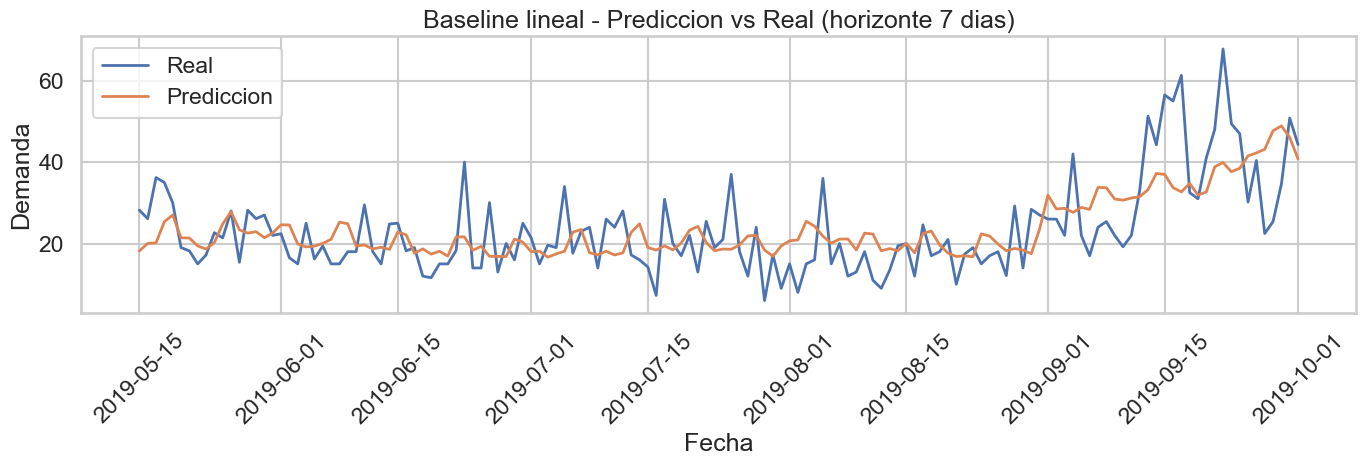

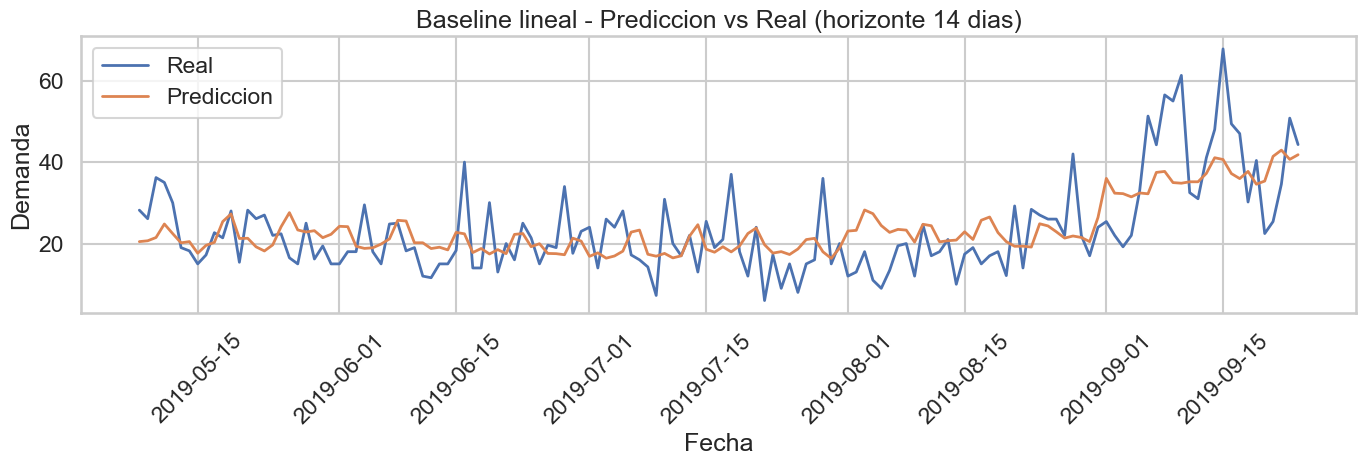

In [12]:
for h in horizons:
    plot_predictions(
        baseline_results[h]["pred_df"],
        title=f"Baseline lineal - Prediccion vs Real (horizonte {h} dias)",
        last_n=140,
    )

## 5) Modeling

In [13]:
def sarima_walk_forward(series, horizon, train_size=0.8, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7)):
    split_idx = int(len(series) * train_size)
    train = series.iloc[:split_idx].copy()
    test = series.iloc[split_idx:].copy()

    model = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    results = model.fit(disp=False)

    preds = []
    actuals = []
    pred_dates = []

    max_i = len(test) - horizon + 1
    for i in range(max_i):
        forecast = results.get_forecast(steps=horizon).predicted_mean.iloc[-1]
        target_pos = i + horizon - 1

        preds.append(float(forecast))
        actuals.append(float(test.iloc[target_pos]))
        pred_dates.append(test.index[target_pos])

        new_obs = pd.Series([test.iloc[i]], index=[test.index[i]])
        try:
            results = results.append(new_obs, refit=False)
        except Exception:
            history = pd.concat([train, test.iloc[: i + 1]])
            fallback_model = SARIMAX(
                history,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            results = fallback_model.fit(disp=False)

    pred_df = pd.DataFrame({"actual": actuals, "predicted": preds}, index=pred_dates)
    pred_df.index.name = "date"

    metric = summarize_metrics(
        model_name="Advanced_SARIMA",
        horizon=horizon,
        y_true=pred_df["actual"],
        y_pred=pred_df["predicted"],
    )
    return pred_df, metric

In [14]:
sarima_results = {}
sarima_metrics_rows = []

series_target = df[target_col].astype(float)

for h in horizons:
    pred_df, metric = sarima_walk_forward(
        series=series_target,
        horizon=h,
        train_size=0.8,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
    )
    sarima_results[h] = {"pred_df": pred_df}
    sarima_metrics_rows.append(metric)

sarima_metrics = pd.DataFrame(sarima_metrics_rows)
sarima_metrics

,Model,Horizon_days,MAE,RMSE
0,Advanced_SARIMA,7,10.254793,13.341202
1,Advanced_SARIMA,14,11.112894,14.660338


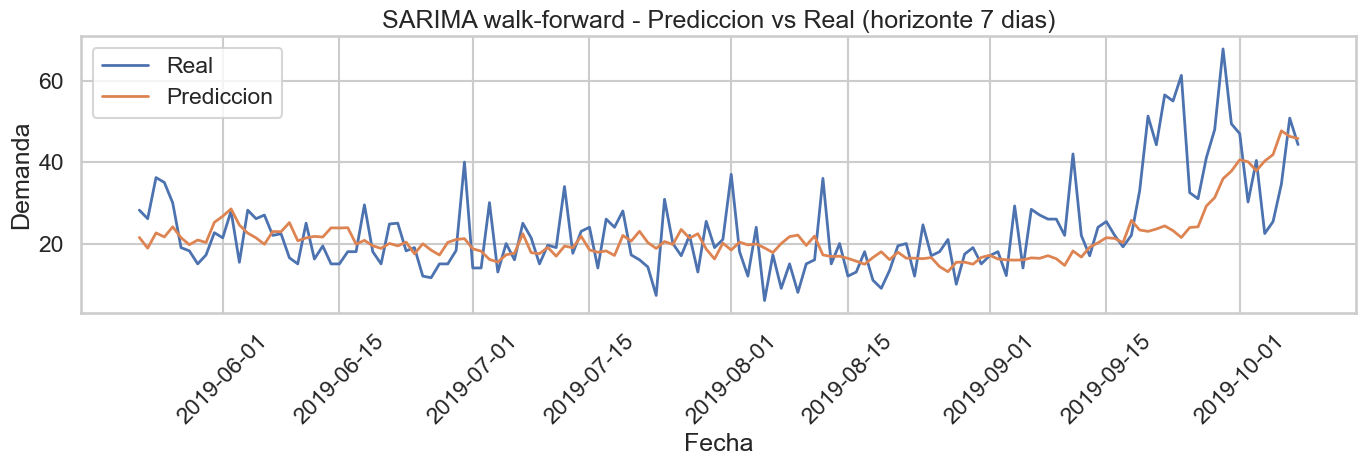

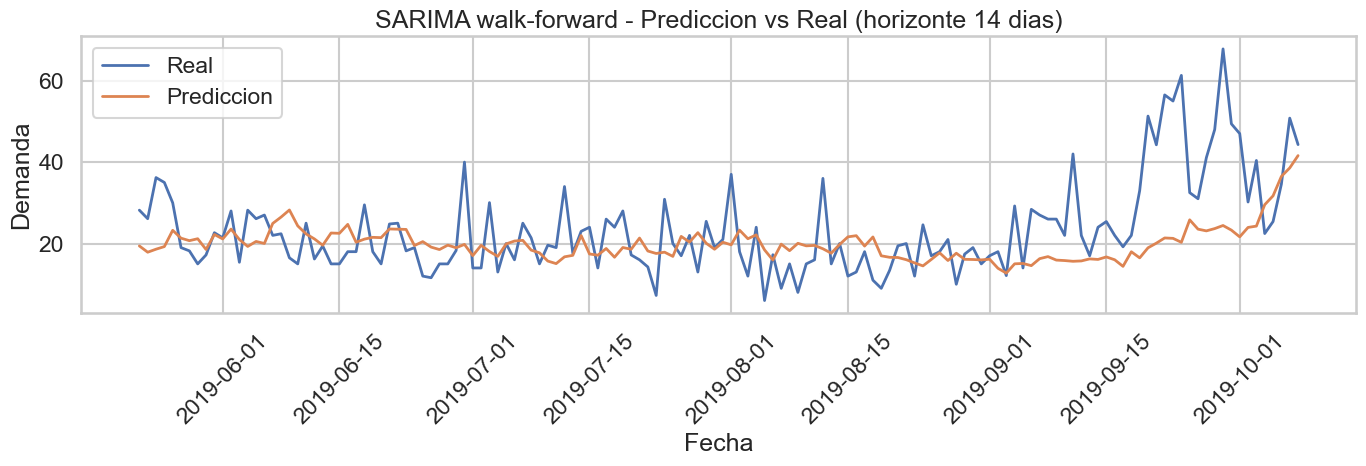

In [15]:
for h in horizons:
    plot_predictions(
        sarima_results[h]["pred_df"],
        title=f"SARIMA walk-forward - Prediccion vs Real (horizonte {h} dias)",
        last_n=140,
    )

## 6) Evaluation

- Menor MAE/RMSE implica mejor estimacion de demanda esperada.
- Mejor control de inventario y menor probabilidad de quiebre de stock.

In [16]:
comparison_df = (
    pd.concat([baseline_metrics, sarima_metrics], ignore_index=True)
    .sort_values(["Horizon_days", "RMSE"])
    .reset_index(drop=True)
)
comparison_df

,Model,Horizon_days,MAE,RMSE
0,Baseline_LinearRegression,7,9.632293,12.708253
1,Advanced_SARIMA,7,10.254793,13.341202
2,Baseline_LinearRegression,14,10.001452,13.202162
3,Advanced_SARIMA,14,11.112894,14.660338


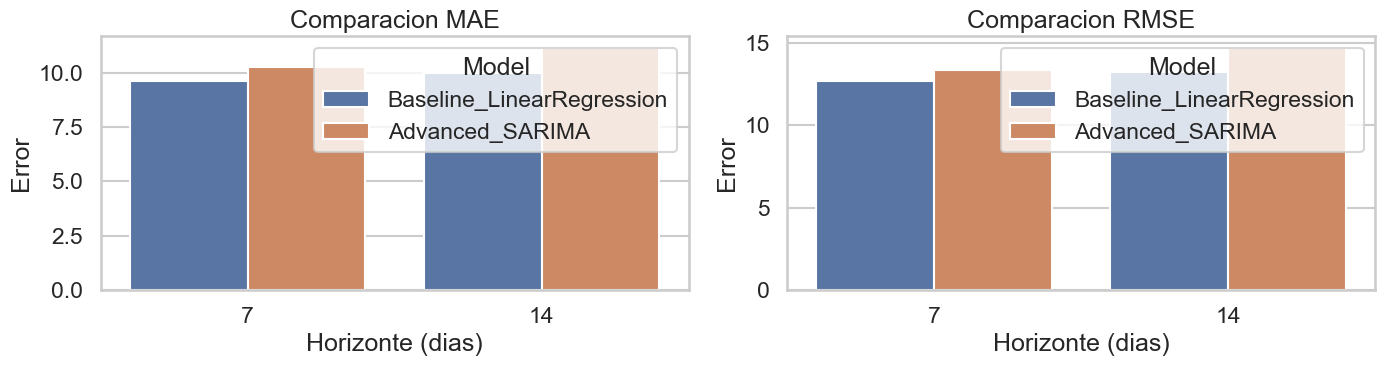

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=comparison_df, x="Horizon_days", y="MAE", hue="Model", ax=axes[0])
axes[0].set_title("Comparacion MAE")

sns.barplot(data=comparison_df, x="Horizon_days", y="RMSE", hue="Model", ax=axes[1])
axes[1].set_title("Comparacion RMSE")

for ax in axes:
    ax.set_xlabel("Horizonte (dias)")
    ax.set_ylabel("Error")

plt.tight_layout()
plt.show()

### Forecast para los proximos 14 dias

,forecast_N02BE
2019-10-09,39.836407
2019-10-10,39.233769
2019-10-11,40.042733
2019-10-12,40.591901
2019-10-13,43.211513
2019-10-14,42.335065
2019-10-15,41.131626
2019-10-16,40.601220
2019-10-17,40.117061
2019-10-18,40.897060


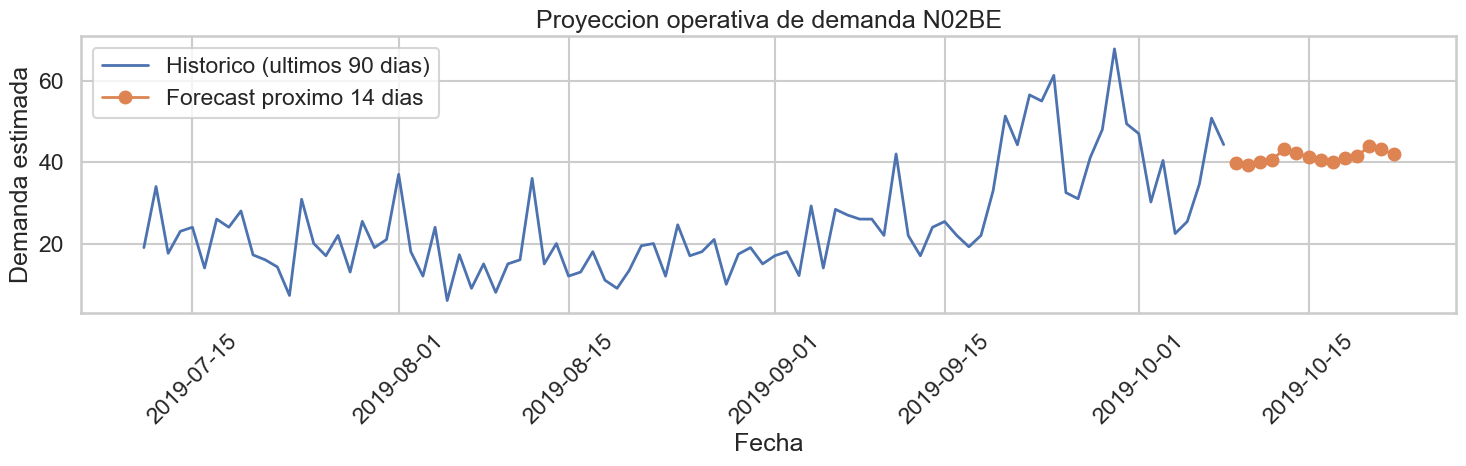

In [18]:
final_sarima = SARIMAX(
    series_target,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

future_steps = 14
future_values = final_sarima.get_forecast(steps=future_steps).predicted_mean
future_dates = pd.date_range(series_target.index.max() + pd.Timedelta(days=1), periods=future_steps, freq="D")
future_df = pd.DataFrame({"forecast_N02BE": future_values.values}, index=future_dates)

display(future_df)

plt.figure(figsize=(15, 5))
plt.plot(series_target.tail(90).index, series_target.tail(90).values, label="Historico (ultimos 90 dias)", linewidth=2)
plt.plot(future_df.index, future_df["forecast_N02BE"], marker="o", label="Forecast proximo 14 dias", linewidth=2)
plt.title("Proyeccion operativa de demanda N02BE")
plt.xlabel("Fecha")
plt.ylabel("Demanda estimada")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7) Conclusiones

1. Se construyo un pipeline completo y reproducible bajo CRISP-DM para demanda de medicamentos.
2. El baseline lineal entrega una referencia interpretable y defendible.
3. SARIMA captura dinamica temporal y estacionalidad semanal, lo que suele mejorar precision en horizontes 7/14 dias.
4. Las metricas MAE y RMSE permiten cuantificar impacto operativo en decisiones de stock.
5. El forecast de 14 dias puede integrarse en una regla de reposicion para ALDIMI (stock de seguridad + lead time).